# Neural Network Fundamentals and Training Behavior Analysis

## Objective
Build and analyze a feed-forward neural network model for customer churn prediction.

This notebook covers:
- Dataset understanding
- Data preprocessing
- Neural network training
- Model evaluation
- Hyperparameter experimentation
- Neural network learning behavior analysis

In [1]:
#importing necessary libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Task 1: Dataset Understanding

BASIC EXPLORATION

In [ ]:
#importing the dataset
df = pd.read_csv("Data/customer_churn_nn.csv")

df.head(10)

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0
5,CUST0006,North,Premium,One-year,Wallet,13,1058.22,13,1,1,157.49,8.3,115,10,0,1,0
6,CUST0007,Central,Standard,Two-year,Debit Card,38,765.73,18,2,0,119.12,7.1,10,0,1,1,0
7,CUST0008,South,Basic,Month-to-month,UPI,16,327.42,11,5,8,32.46,6.9,99,0,0,0,0
8,CUST0009,South,Premium,Month-to-month,Debit Card,19,1050.49,22,0,2,136.53,6.0,7,20,0,0,0
9,CUST0010,Central,Standard,One-year,Credit Card,20,732.89,14,3,1,115.10,6.4,0,20,0,0,0


In [ ]:
#checking the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


In [ ]:
print("\nColumn Data Types:\n")
print(df.dtypes)


Column Data Types:

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [ ]:
#checking for missing values
print("\nMissing Values:\n")
print(df.isna().sum())


Missing Values:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [ ]:
#Statistical summary of the dataset
print("\nStatistical Summary:\n")
print(df.describe(include="all").T)


Statistical Summary:

                               count unique             top  freq        mean  \
customer_id                     2000   2000        CUST0001     1         NaN   
region                          2000      5            West   417         NaN   
plan_type                       2000      4        Standard   718         NaN   
contract_type                   2000      3  Month-to-month  1111         NaN   
payment_method                  2000      5     Credit Card   411         NaN   
tenure_months                 2000.0    NaN             NaN   NaN      25.362   
monthly_charges_inr           2000.0    NaN             NaN   NaN  766.487295   
avg_login_days_per_month      2000.0    NaN             NaN   NaN      18.099   
support_tickets_last_90_days  2000.0    NaN             NaN   NaN       1.953   
payment_delay_days            2000.0    NaN             NaN   NaN       3.555   
data_usage_gb                 2000.0    NaN             NaN   NaN   90.007625   
satis

TARGET VARIABLE ANALYSIS

In [ ]:
#checking class distribution
print(df["churn"].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


In [ ]:
#checking class distribution in percentage
print(
    round(
        df["churn"].value_counts(normalize=True) * 100,
        2
    )
)

churn
0    98.45
1     1.55
Name: proportion, dtype: float64


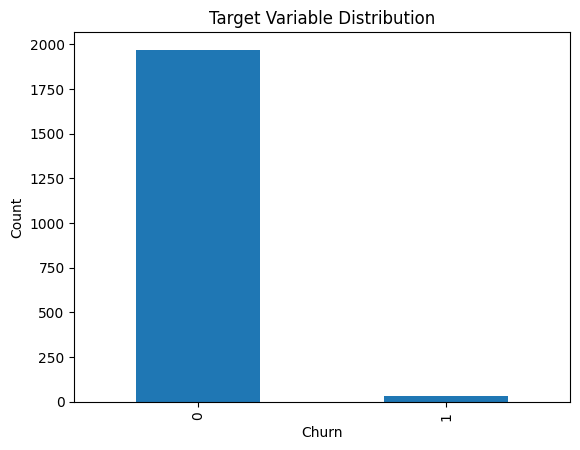

In [ ]:
#visualizing class distribution
df["churn"].value_counts().plot(kind="bar")

plt.title("Target Variable Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

## Task 2: Data Preprocessing

In [ ]:
#Separating features and target variable
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]

In [ ]:
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]

In [12]:
categorical_cols = [
    "region",
    "plan_type",
    "contract_type",
    "payment_method"
]

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

print("Categorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)

Categorical Columns:
['region', 'plan_type', 'contract_type', 'payment_method']

Numeric Columns:
['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']


In [ ]:
#Train-test split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [16]:
print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (1600, 28)
Processed Testing Shape: (400, 28)


In [ ]:
#Calculating class weights to handle class imbalance
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))

print(class_weight)

{np.int64(0): np.float64(0.5079365079365079), np.int64(1): np.float64(32.0)}


## Task 3: Neural Network Model Building

In [18]:
def build_model(
    input_dim,
    hidden_layers=[64, 32],
    learning_rate=0.001,
    dropout_rate=0.0
):

    model = keras.Sequential()

    model.add(
        layers.Input(shape=(input_dim,))
    )

    for units in hidden_layers:

        model.add(
            layers.Dense(
                units,
                activation="relu"
            )
        )

        if dropout_rate > 0:
            model.add(
                layers.Dropout(dropout_rate)
            )

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

## Task 4: Training and Evaluation

In [19]:
baseline_model = build_model(
    input_dim=X_train_processed.shape[1],
    hidden_layers=[64, 32],
    learning_rate=0.001
)

In [20]:
history = baseline_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.4875 - auc: 0.5808 - loss: 0.7294 - val_accuracy: 0.6500 - val_auc: 0.8475 - val_loss: 0.6358
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7055 - auc: 0.8265 - loss: 0.6131 - val_accuracy: 0.7063 - val_auc: 0.8970 - val_loss: 0.5717
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7500 - auc: 0.8832 - loss: 0.5343 - val_accuracy: 0.7188 - val_auc: 0.9127 - val_loss: 0.5496
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7750 - auc: 0.9140 - loss: 0.4708 - val_accuracy: 0.7719 - val_auc: 0.9261 - val_loss: 0.4680
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7906 - auc: 0.9312 - loss: 0.4217 - val_accuracy: 0.8281 - val_auc: 0.9347 - val_loss: 0.3998
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8313 - auc: 0.9422 - loss: 0.3802 - val_accuracy: 0.7906 - val_auc: 0.9363 - val_loss: 0.4316
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

In [21]:
test_probabilities = baseline_model.predict(
    X_test_processed
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [22]:
accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    test_probabilities
)

In [23]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", auc)

Accuracy: 0.93
Precision: 0.10714285714285714
Recall: 0.5
F1 Score: 0.17647058823529413
ROC-AUC: 0.8299492385786802


In [24]:
print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       394
           1       0.11      0.50      0.18         6

    accuracy                           0.93       400
   macro avg       0.55      0.72      0.57       400
weighted avg       0.98      0.93      0.95       400



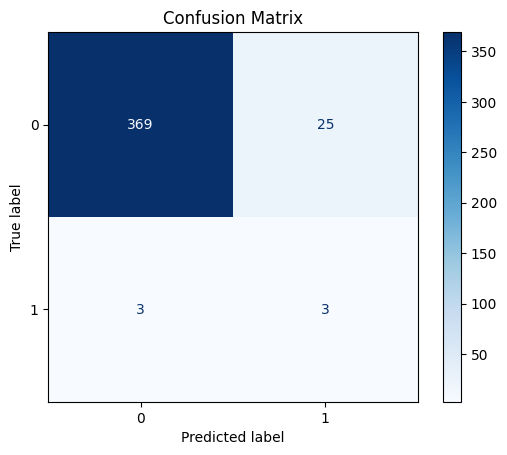

In [25]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

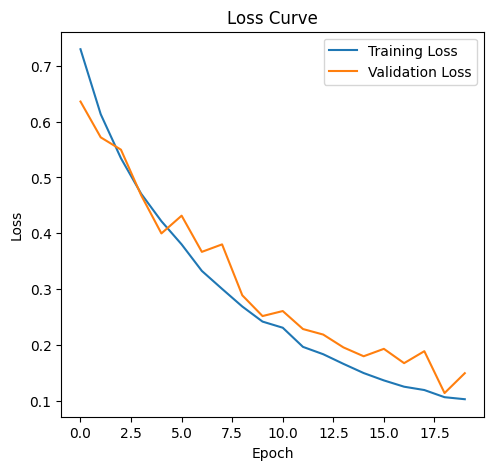

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

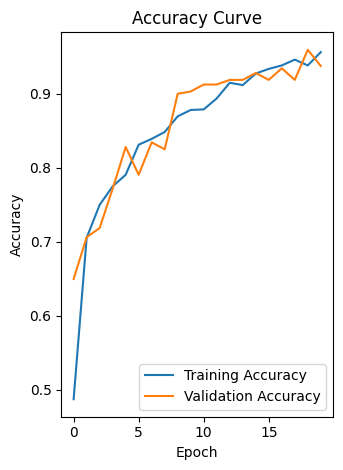

In [27]:
plt.subplot(1, 2, 2)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()

plt.show()

## Task 5: Hyperparameter Experimentation

In [28]:
experiments = [

    {
        "name": "Experiment 1",
        "hidden_layers": [32],
        "lr": 0.001,
        "batch_size": 32,
        "epochs": 20,
        "dropout": 0.0
    },

    {
        "name": "Experiment 2",
        "hidden_layers": [64, 32],
        "lr": 0.001,
        "batch_size": 32,
        "epochs": 20,
        "dropout": 0.0
    },

    {
        "name": "Experiment 3",
        "hidden_layers": [64, 32],
        "lr": 0.0005,
        "batch_size": 64,
        "epochs": 25,
        "dropout": 0.2
    }
]

In [29]:
results = []

In [30]:
for exp in experiments:

    tf.keras.backend.clear_session()

    model = build_model(
        input_dim=X_train_processed.shape[1],
        hidden_layers=exp["hidden_layers"],
        learning_rate=exp["lr"],
        dropout_rate=exp["dropout"]
    )

    model.fit(
        X_train_processed,
        y_train,
        validation_split=0.2,
        epochs=exp["epochs"],
        batch_size=exp["batch_size"],
        class_weight=class_weight,
        verbose=0
    )

    probabilities = model.predict(
        X_test_processed,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    results.append({

        "Experiment":
            exp["name"],

        "Hidden Layers":
            str(exp["hidden_layers"]),

        "Learning Rate":
            exp["lr"],

        "Batch Size":
            exp["batch_size"],

        "Epochs":
            exp["epochs"],

        "Dropout":
            exp["dropout"],

        "Accuracy":
            accuracy_score(
                y_test,
                predictions
            ),

        "Precision":
            precision_score(
                y_test,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                predictions,
                zero_division=0
            ),

        "F1 Score":
            f1_score(
                y_test,
                predictions,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_test,
                probabilities
            )
    })

In [31]:
results_df = pd.DataFrame(results)

results_df

,Experiment,Hidden Layers,Learning Rate,Batch Size,Epochs,Dropout,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Experiment 1,[32],0.0010,32,20,0.0,0.810,0.062500,0.833333,0.116279,0.864213
1,Experiment 2,"[64, 32]",0.0010,32,20,0.0,0.935,0.083333,0.333333,0.133333,0.838409
2,Experiment 3,"[64, 32]",0.0005,64,25,0.2,0.815,0.064103,0.833333,0.119048,0.909898


In [32]:
os.makedirs("results", exist_ok=True)

In [33]:
results_df.to_csv(
    "results/model_comparison_table.csv",
    index=False
)

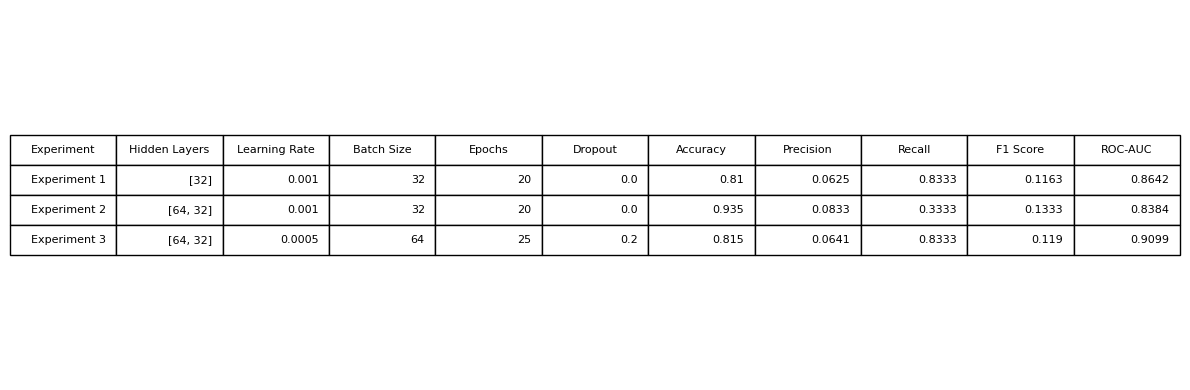

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.axis("off")

table = ax.table(
    cellText=results_df.round(4).values,
    colLabels=results_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

plt.tight_layout()

plt.savefig(
    "results/evaluation_outputs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 6: Final Reflection

## 1. What role do weights and biases play in the model?

Weights determine how strongly each input feature influences the prediction made by the neural network. During training, the model continuously adjusts these weights using backpropagation in order to minimize prediction error.

Biases help shift the activation values of neurons and improve the flexibility of the model. Without biases, the neural network would be limited in its ability to learn complex relationships from the data.

---

## 2. Why is an activation function required?

Activation functions introduce non-linearity into the neural network. Without activation functions, even multiple neural network layers would behave like a simple linear model.

The ReLU activation function used in the hidden layers helped the model learn more complex feature relationships, while the sigmoid activation function in the output layer converted predictions into probabilities for binary classification.

---

## 3. What happens when learning rate is too high or too low?

The learning rate controls how much the model updates its weights during training.

If the learning rate is too high, the model may overshoot the optimal solution and training can become unstable. This may prevent convergence and reduce overall performance.

If the learning rate is too low, the model learns very slowly and may require many epochs to reach a good solution.

In the experiments performed, reducing the learning rate from 0.001 to 0.0005 improved the ROC-AUC score from 0.8384 to 0.9099, showing that a smaller learning rate allowed the model to learn more stable patterns from the data.

---

## 4. Did the model show signs of underfitting or overfitting?

The model showed some challenges related to class imbalance in the dataset. Although the accuracy values were relatively high, the precision and F1 scores remained low across experiments.

Experiment 2 achieved the highest accuracy (93.5%), but recall dropped significantly to 33.33%, indicating that the model missed many churn cases.

Experiments 1 and 3 achieved much higher recall values (83.33%), which means they were better at identifying churned customers. Experiment 3 produced the best ROC-AUC score (0.9099), suggesting better overall classification capability.

The results indicate that the model did not strongly overfit, but performance was affected by the highly imbalanced target variable. The experiments demonstrated the trade-off between accuracy and recall, which is common in imbalanced classification problems.